# <a id="#">Task 3 – Mean, median, and Gaussian filtering</a>

In [3]:
import numpy
import matplotlib.pyplot as plt

---

## Linear filtering by convolution (mean filter)

**<a id="#">Task 3.1.1.</a>** Load the image `data/astronaut.png` and show it:

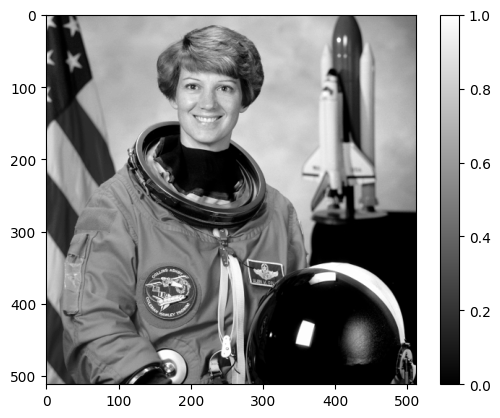

In [4]:
img = plt.imread('data/astronaut.png')

plt.imshow(img, 'grey')

plt.colorbar ()

**<a id="#">Task 3.1.2.</a>** Implement a mean filter:

In [5]:
def meanfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    n = (size - 1) // 2
    
    for p in numpy.ndindex(img_in.shape):
        # Die Bedingung fürs Border Problem:
        # Prüfe, ob der aktuelle Punkt p mindestens 'n' Abstand zum Rand hat
        if (n <= p[0] < img_in.shape[0] - n) and (n <= p[1] < img_in.shape[1] - n):
            
            neighborhood_sum = 0
            for q in numpy.ndindex(size, size):
                y_img = p[0] + q[0] - n
                x_img = p[1] + q[1] - n
                neighborhood_sum += img_in[y_img, x_img]
            
            result[p] = neighborhood_sum / (size * size)
        
        # Falls das 'if' nicht zutrifft (Randbereich), passiert nichts.
        # Da result mit zeros initialisiert wurde, bleibt result[p] dort 0.0.
            
    return result

**<a id="#">Task 3.1.3.</a>** Test your implementation from above by using the function `meanfilter` for the previously loaded image and show the result:

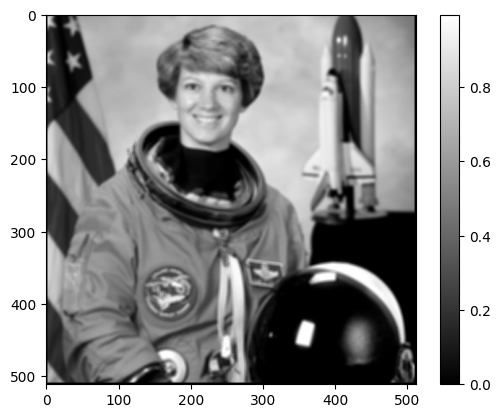

In [6]:
img_mean = meanfilter(img, 5)
plt.imshow(img_mean, 'grey')
plt.colorbar ()

**<a id="#">Task 3.1.4.</a>** Compare your result for filter size `5` with the correct result image `data/astronaut_meanfilter5.png`:

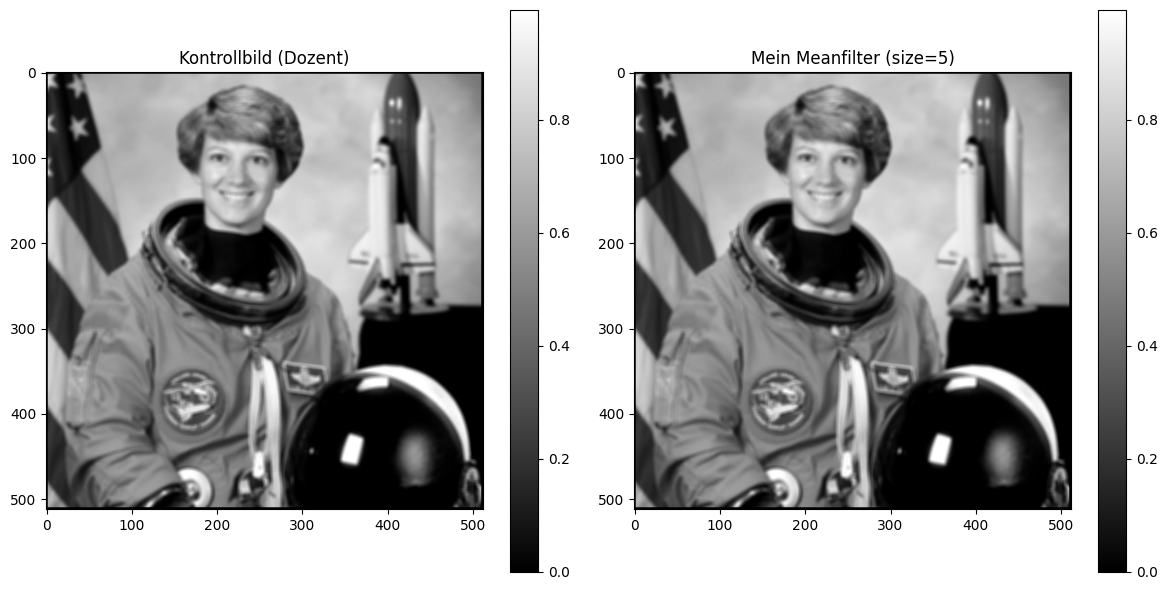

Vergleich erfolgreich: Die Bilder sind identisch!


In [8]:
# 1. Daten vorbereiten
controll_img_mean = plt.imread('data/astronaut_meanfilter5.png')
# img_mean wurde bereits durch deine Funktion berechnet

# 2. Eine Figur erstellen, die groß genug für zwei Bilder ist
plt.figure(figsize=(12, 6))

# --- Linkes Bild (Das Kontrollbild) ---
# (1 Reihe, 2 Spalten, Position 1)
plt.subplot(1, 2, 1)
plt.imshow(controll_img_mean, cmap='gray')
plt.title('Kontrollbild (Dozent)')
plt.colorbar()

# --- Rechtes Bild (Dein Ergebnis) ---
# (1 Reihe, 2 Spalten, Position 2)
plt.subplot(1, 2, 2)
plt.imshow(img_mean, cmap='gray')
plt.title('Mein Meanfilter (size=5)')
plt.colorbar()

# 3. Das Layout optimieren (verhindert Überlappungen)
plt.tight_layout()
plt.show()

# 4. Der Test (wird im Hintergrund ausgeführt)
assert numpy.allclose(img_mean, controll_img_mean, atol=1/255)
print("Vergleich erfolgreich: Die Bilder sind identisch!")

---

## Non-linear filtering

**<a id="#">Task 3.2.1.</a>** Implement a median filter:

In [12]:
def medianfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    
    # 2. Radius n und Fenstergröße N berechnen
    n = (size - 1) // 2
    N = size
    
    # 3. Schleife über das "innere" Bild
    # Wir ziehen 2*n von der Form ab, damit wir nicht über den Rand laufen
    for p in numpy.ndindex(img_in.shape[0] - 2*n, img_in.shape[1] - 2*n):
        
        # p[0] ist die y-Koordinate, p[1] die x-Koordinate
        # Wir schneiden das N x N Fenster aus dem Originalbild aus
        # Der Bereich geht von p bis p+N
        neighborhood = img_in[p[0] : p[0] + N, p[1] : p[1] + N]
        
        # In eine flache Liste umwandeln und sortieren
        values = neighborhood.flatten()
        values.sort()
        med = values[len(values) // 2]
        
        # Den Median-Wert an der korrekten Stelle im result speichern.
        # WICHTIG: Wir addieren +n, damit das Ergebnis zentriert im Bild liegt
        result[p[0] + n, p[1] + n] = med
        
    return result

**<a id="#">Task 3.2.2.</a>** First, test your implementation from above by using the function `medianfilter` for the previously loaded image and show the result:

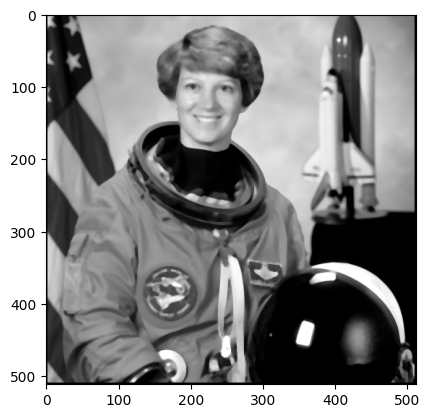

In [13]:
img_median = medianfilter(img, 5)
plt.imshow(img_median, 'grey')

Then, compare your result for filter size `5` with the correct result image `data/astronaut_medianfilter5.png`:

Vergleich erfolgreich: Die Bilder sind identisch!


array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

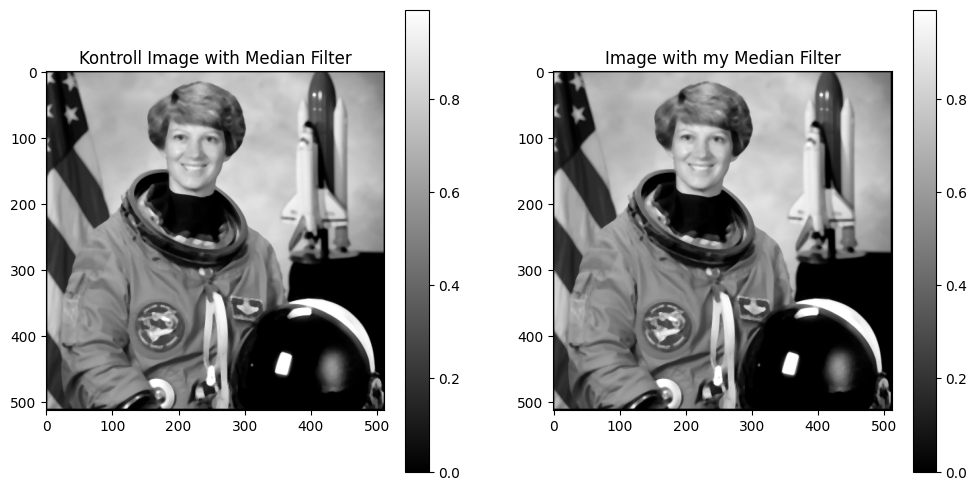

In [ ]:
controll_img_median = plt.imread('data/astronaut_medianfilter5.png')

plt.figure(figsize=(12, 6))

plt.subplot (1,2,1)
plt.imshow(controll_img_median, 'grey')
plt.title ("Kontroll Image with Median Filter")
plt.colorbar()

plt.subplot (1,2,2)
plt.imshow(img_median, 'grey')
plt.title ("Image with my Median Filter")
plt.colorbar()

# 4. Der Test (wird im Hintergrund ausgeführt)
assert numpy.allclose(img_median, controll_img_median, atol=1/255)
print("Vergleich erfolgreich: Die Bilder sind identisch!")
img_median == controll_img_median

---

## Using pre-implemented filters

**<a id="#">Task 3.3.1.</a>** Load the package `scipy.ndimage`:

**<a id="#">Task 3.3.2 (a).</a>** Apply a **mean filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.2 (b).</a>** Apply a **median filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.2 (c).</a>** Apply a **Gaussian filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.3.</a>** Compare the results obtained using the functions from `scipy.ndimage` with those you obtained using your own implementations. What are the main differences? Do you have an explanation?

---

## Slicing and benchmarking

**<a id="#">Task 3.4.2.</a>** Implement either a mean filter or a median filter using only a single `for`-loop:

In [ ]:
def fastfilter(img_in, size):
    ...

**<a id="#">Task 3.4.3.</a>** First, test your implementation from above by using the function `fastfilter` for the previously loaded image and show the result:

Then, compare your result to those obtained using your implementation for either `meanfilter` or `medianfilter`, respectively:

**<a id="#">Task 3.4.4.</a>** Benchmark the code run times:

**<a id="#">Task 3.4.5.</a>** Document your observations regarding the benchmarking results and try to think of an explanation: